In [1]:
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
file_path = "../data/bmrcl/station-hourly.csv"

df = pd.read_csv(file_path, sep=";")

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
         Date  Hour    Station  Ridership
0  2025-08-01     0  Attiguppe          0
1  2025-08-01     1  Attiguppe          0
2  2025-08-01     2  Attiguppe          0
3  2025-08-01     3  Attiguppe          0
4  2025-08-01     4  Attiguppe          6


In [3]:
print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Dataset shape:
(92280, 4)

Column names:
['Date', 'Hour', 'Station', 'Ridership']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 92280 entries, 0 to 92279
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Date       92280 non-null  str  
 1   Hour       92280 non-null  int64
 2   Station    92280 non-null  str  
 3   Ridership  92280 non-null  int64
dtypes: int64(2), str(2)
memory usage: 2.8 MB


In [4]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
Date         0
Hour         0
Station      0
Ridership    0
dtype: int64

Duplicate rows:
0


In [5]:
# Number of unique stations and dates

print("Number of unique stations:")
print(df["Station"].nunique())

print("\nNumber of unique dates:")
print(df["Date"].nunique())

print("\nHour range:")
print(df["Hour"].min(), "to", df["Hour"].max())

print("\nSample station names:")
print(df["Station"].unique()[:10])

Number of unique stations:
83

Number of unique dates:
48

Hour range:
0 to 23

Sample station names:
<StringArray>
[        'Attiguppe',   'Baiyappanahalli',      'Banashankari',
    'Benniganahalli',      'Challaghatta',         'Chickpete',
 'Chikkabidarakallu',       'Cubbon Park',       'Dasarahalli',
  'Deepanjali Nagar']
Length: 10, dtype: str


In [6]:
# Hourly ridership analysis

hourly_ridership = df.groupby("Hour")["Ridership"].sum()

print("Total ridership by hour:")
print(hourly_ridership)

print("\nPeak hour:")
print(hourly_ridership.idxmax(), "with",
      hourly_ridership.max(), "passengers")

print("\nLowest ridership hour:")
print(hourly_ridership.idxmin(), "with",
      hourly_ridership.min(), "passengers")

Total ridership by hour:
Hour
0         666
1           0
2           0
3         628
4       45473
5      214570
6      535167
7     1430096
8     2633907
9     3105111
10    2273407
11    1731081
12    1660593
13    1719524
14    1699369
15    1830167
16    2313129
17    2870284
18    3330084
19    2740976
20    1823085
21    1159397
22     635188
23      85980
Name: Ridership, dtype: int64

Peak hour:
18 with 3330084 passengers

Lowest ridership hour:
1 with 0 passengers


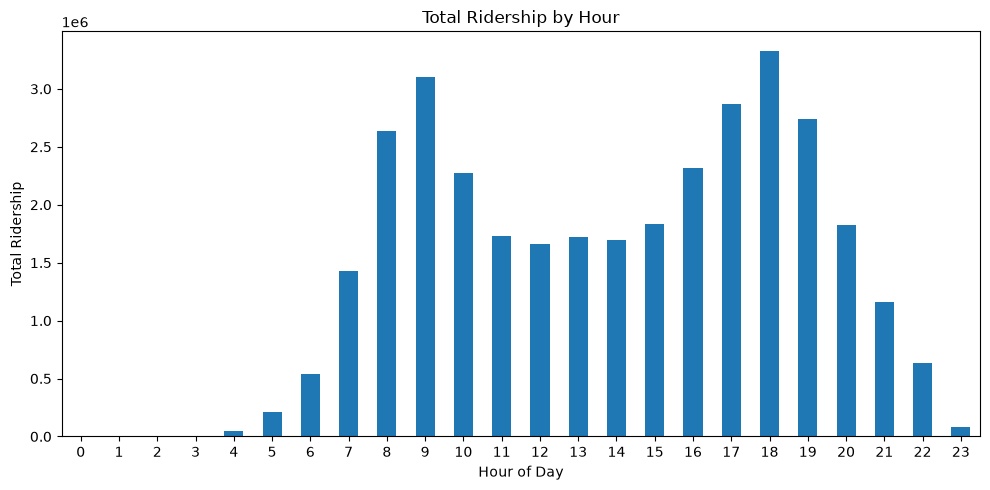

In [7]:
# Hourly ridership visualization

hourly_ridership.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Total Ridership by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Total Ridership")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [8]:
# Station-wise ridership analysis

station_ridership = (
    df.groupby("Station")["Ridership"]
    .sum()
    .sort_values(ascending=False)
)

print("Top 10 busiest stations:")
print(station_ridership.head(10))

Top 10 busiest stations:
Station
Nadaprabhu Kempegowda Station, Majestic    1649530
Benniganahalli                             1250656
Indiranagar                                1048936
Mahatma Gandhi Road                        1007176
Krishnarajapura                             904508
Mantri Square Sampige Road                  796520
Chickpete                                   737856
Cubbon Park                                 666237
Yeshwantpur                                 666189
Baiyappanahalli                             644624
Name: Ridership, dtype: int64


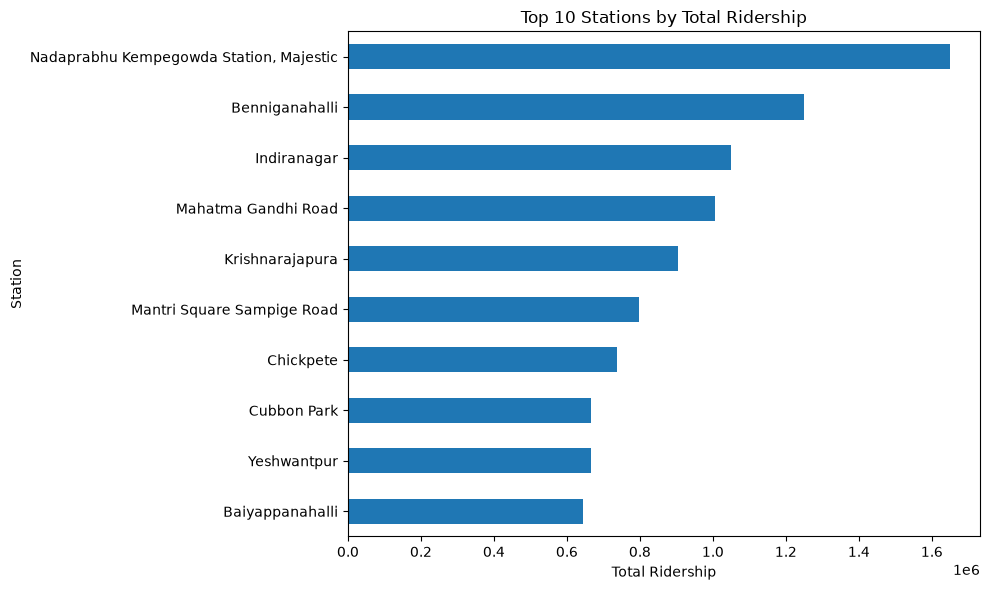

In [9]:
# Top 10 busiest stations visualization

top_10_stations = station_ridership.head(10)

top_10_stations.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Stations by Total Ridership")
plt.xlabel("Total Ridership")
plt.ylabel("Station")
plt.tight_layout()

plt.show()

In [10]:
# Daily ridership analysis

daily_ridership = (
    df.groupby("Date")["Ridership"]
    .sum()
    .sort_index()
)

print("Daily total ridership:")
print(daily_ridership)

print("\nHighest ridership day:")
print(
    daily_ridership.idxmax(),
    "with",
    daily_ridership.max(),
    "passengers"
)

print("\nLowest ridership day:")
print(
    daily_ridership.idxmin(),
    "with",
    daily_ridership.min(),
    "passengers"
)

Daily total ridership:
Date
2025-08-01    670548
2025-08-02    628845
2025-08-03    498746
2025-08-04    708417
2025-08-05    687984
2025-08-06    732508
2025-08-07    714243
2025-08-08    545543
2025-08-09    565926
2025-08-10    482205
2025-08-11    795066
2025-08-12    778020
2025-08-13    800230
2025-08-14    843684
2025-08-15    668554
2025-08-16    667298
2025-08-17    542547
2025-08-18    786247
2025-09-01    756329
2025-09-02    760983
2025-09-03    788645
2025-09-04    783453
2025-09-05    648115
2025-09-06    651050
2025-09-07    499672
2025-09-08    761161
2025-09-09    758275
2025-09-10    775226
2025-09-11    757245
2025-09-12    777174
2025-09-13    670063
2025-09-14    556415
2025-09-15    780109
2025-09-16    775833
2025-09-17    795721
2025-09-18    793717
2025-09-19    795987
2025-09-20    719661
2025-09-21    491549
2025-09-22    774431
2025-09-23    765886
2025-09-24    781235
2025-09-25    780549
2025-09-26    783401
2025-09-27    690397
2025-09-28    526641
2025-0

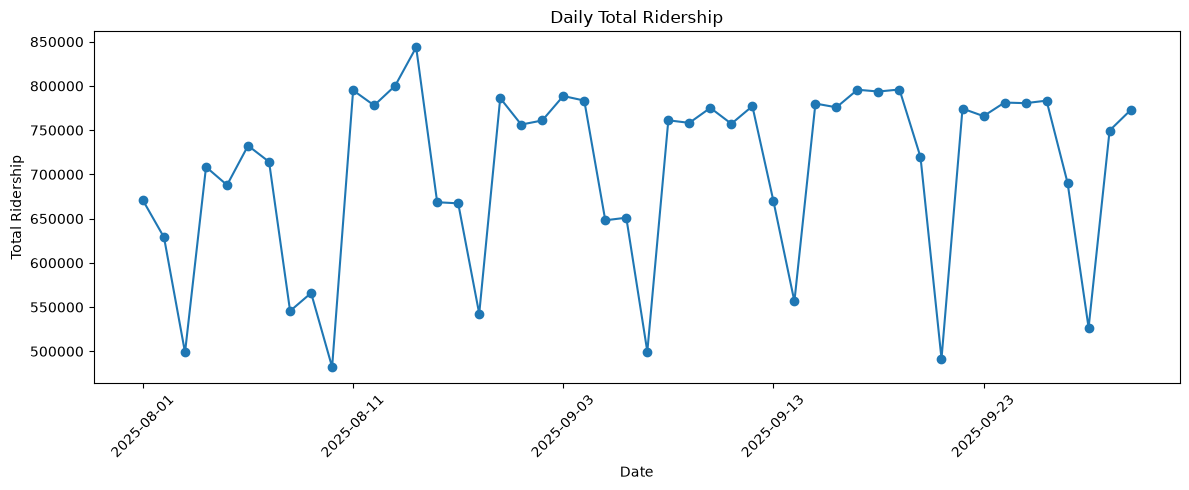

In [11]:
# Daily ridership visualization

daily_ridership.plot(
    kind="line",
    figsize=(12, 5),
    marker="o"
)

plt.title("Daily Total Ridership")
plt.xlabel("Date")
plt.ylabel("Total Ridership")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [12]:
# Peak and off-peak analysis

def classify_period(hour):
    if 7 <= hour <= 10:
        return "Morning Peak"
    elif 17 <= hour <= 20:
        return "Evening Peak"
    elif 11 <= hour <= 16:
        return "Midday"
    else:
        return "Off-Peak"


df["Period"] = df["Hour"].apply(classify_period)

period_ridership = df.groupby("Period")["Ridership"].agg(
    Total_Ridership="sum",
    Average_Ridership="mean"
)

print("Ridership by period:")
print(period_ridership)

print("\nPeriod with highest average ridership:")
print(
    period_ridership["Average_Ridership"].idxmax()
)

Ridership by period:
              Total_Ridership  Average_Ridership
Period                                          
Evening Peak         10764429         699.897854
Midday               10953863         474.809840
Morning Peak          9442521         613.948049
Off-Peak              2677069          69.624681

Period with highest average ridership:
Evening Peak


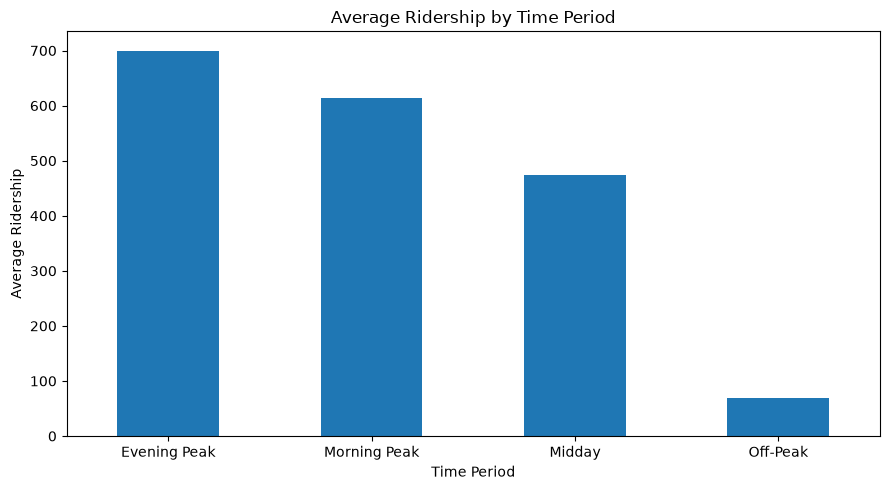

In [13]:
# Peak and off-peak ridership visualization

period_ridership["Average_Ridership"].sort_values(
    ascending=False
).plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Average Ridership by Time Period")
plt.xlabel("Time Period")
plt.ylabel("Average Ridership")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [14]:
# Weekday vs weekend analysis

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Create day of week
df["Day"] = df["Date"].dt.day_name()

# Ridership by day of week
day_ridership = df.groupby("Day")["Ridership"].agg(
    Total_Ridership="sum",
    Average_Ridership="mean"
)

# Arrange days in calendar order
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_ridership = day_ridership.reindex(day_order)

print("Ridership by day of week:")
print(day_ridership)

print("\nDay with highest average ridership:")
print(day_ridership["Average_Ridership"].idxmax())

print(
    "Average ridership:",
    day_ridership["Average_Ridership"].max()
)

# Classify weekday and weekend
df["Day_Type"] = df["Date"].dt.dayofweek.apply(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

# Compare weekday vs weekend
day_type_ridership = df.groupby("Day_Type")["Ridership"].agg(
    Total_Ridership="sum",
    Average_Ridership="mean"
)

print("\nWeekday vs Weekend ridership:")
print(day_type_ridership)

Ridership by day of week:
           Total_Ridership  Average_Ridership
Day                                          
Monday             6111371         392.358179
Tuesday            5299718         390.144140
Wednesday          4673565         401.509021
Thursday           4672891         402.280561
Friday             4889322         368.393761
Saturday           4593240         344.837838
Sunday             3597775         271.080093

Day with highest average ridership:
Thursday
Average ridership: 402.28056129476585

Weekday vs Weekend ridership:
          Total_Ridership  Average_Ridership
Day_Type                                    
Weekday          25646867         390.434585
Weekend           8191015         308.025534


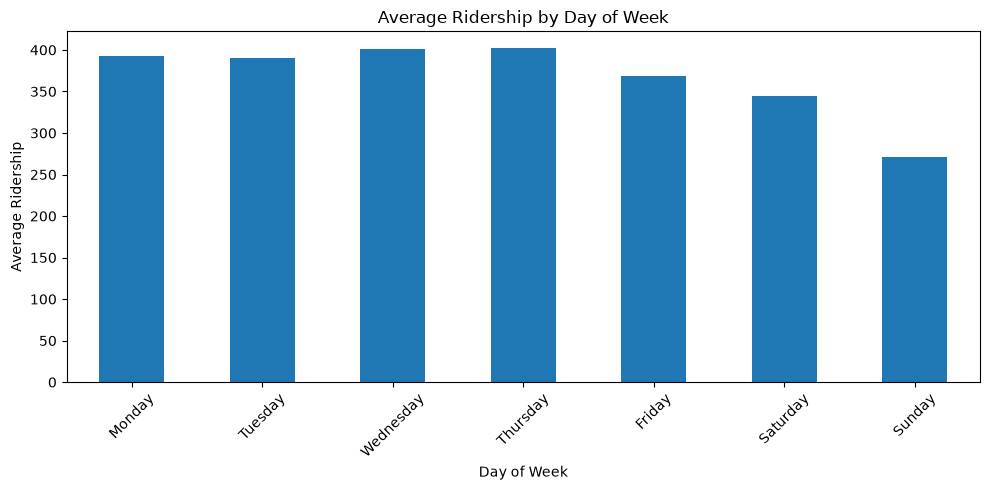

In [15]:
# Average ridership by day of week

day_ridership["Average_Ridership"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Average Ridership by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Ridership")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [16]:
# Busiest station-hour combinations

station_hour_ridership = (
    df.groupby(["Station", "Hour"])["Ridership"]
    .sum()
    .sort_values(ascending=False)
)

print("Top 20 busiest station-hour combinations:")
print(station_hour_ridership.head(20))

Top 20 busiest station-hour combinations:
Station                                     Hour
Mahatma Gandhi Road                         18      159547
Benniganahalli                              9       154784
Mahatma Gandhi Road                         19      142517
Indiranagar                                 18      142005
Trinity                                     18      134575
Cubbon Park                                 18      131980
Benniganahalli                              10      128253
Nadaprabhu Kempegowda Station, Majestic     18      125602
Benniganahalli                              8       124526
Nadaprabhu Kempegowda Station, Majestic     19      123100
Indiranagar                                 19      119829
Nadaprabhu Kempegowda Station, Majestic     17      116148
Baiyappanahalli                             9       113272
Mahatma Gandhi Road                         17      112267
Nadaprabhu Kempegowda Station, Majestic     9       111541
Dr. B. R. Ambedkar Stati

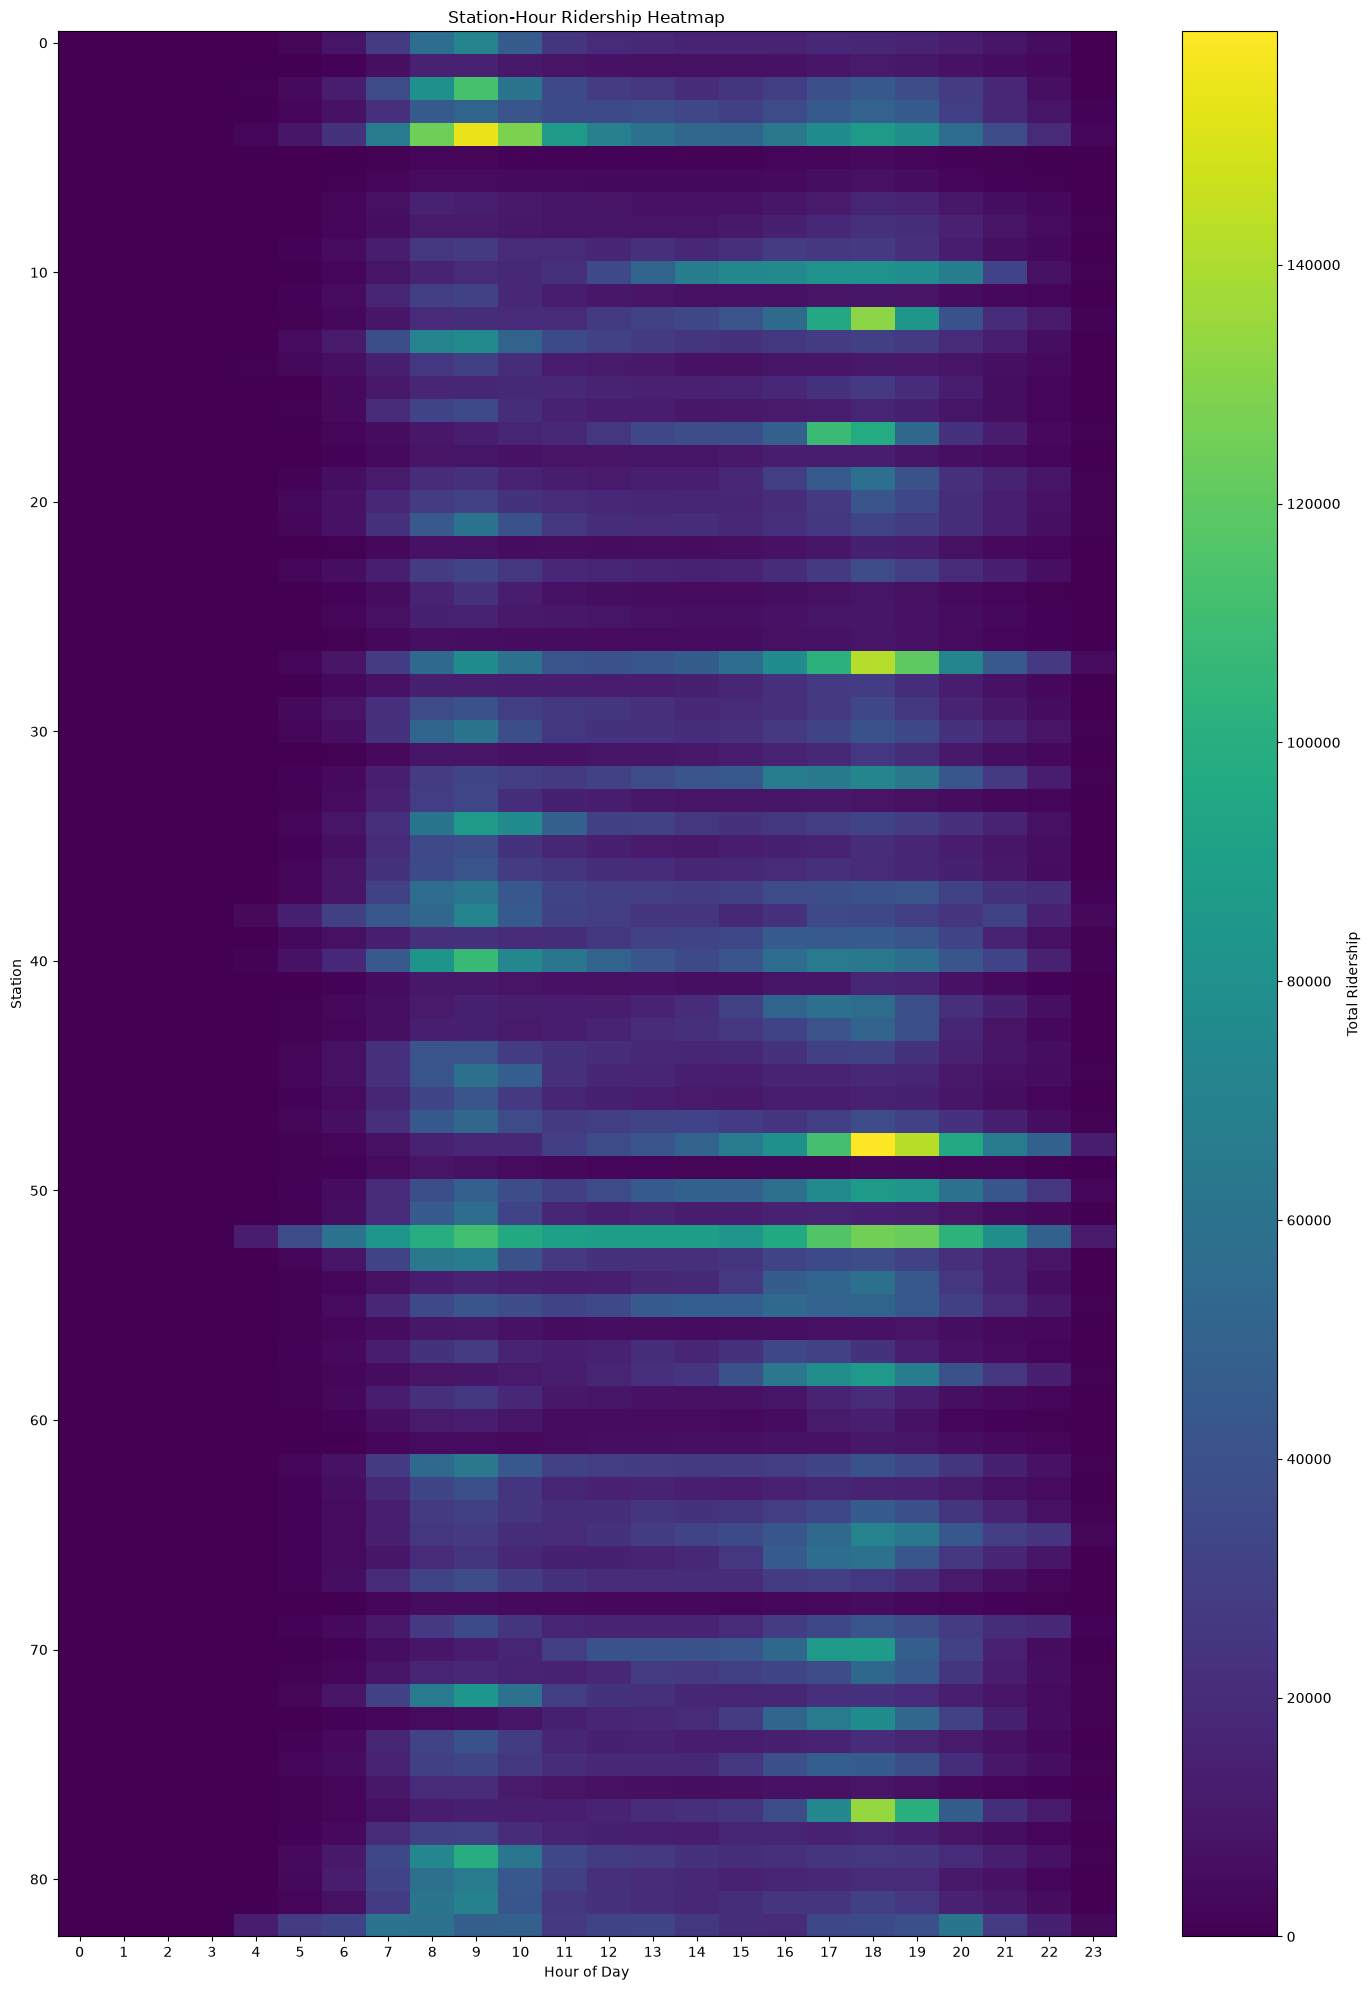

In [17]:
# Station-hour ridership heatmap

station_hour_matrix = df.pivot_table(
    index="Station",
    columns="Hour",
    values="Ridership",
    aggfunc="sum"
)

plt.figure(figsize=(14, 20))

plt.imshow(
    station_hour_matrix,
    aspect="auto"
)

plt.colorbar(label="Total Ridership")

plt.title("Station-Hour Ridership Heatmap")
plt.xlabel("Hour of Day")
plt.ylabel("Station")

plt.xticks(range(24), range(24))

plt.tight_layout()

plt.show()

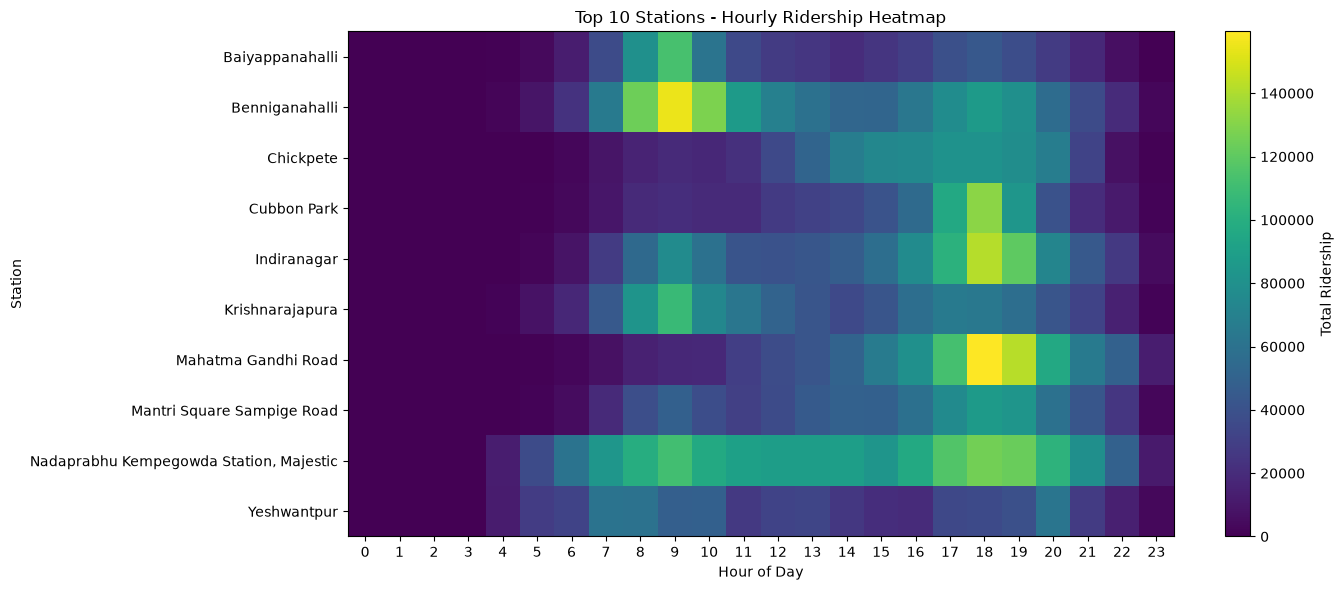

In [18]:
# Top 10 stations - hourly ridership heatmap

top_10_station_names = station_ridership.head(10).index

top_10_hourly = df[df["Station"].isin(top_10_station_names)]

heatmap_data = top_10_hourly.pivot_table(
    index="Station",
    columns="Hour",
    values="Ridership",
    aggfunc="sum"
)

plt.figure(figsize=(14, 6))

plt.imshow(
    heatmap_data,
    aspect="auto"
)

plt.colorbar(label="Total Ridership")

plt.title("Top 10 Stations - Hourly Ridership Heatmap")
plt.xlabel("Hour of Day")
plt.ylabel("Station")

plt.xticks(range(24), range(24))

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.tight_layout()
plt.show()

In [19]:
# Peak and off-peak analysis

def classify_period(hour):
    if 7 <= hour <= 10:
        return "Morning Peak"
    elif 17 <= hour <= 20:
        return "Evening Peak"
    elif 11 <= hour <= 16:
        return "Midday"
    else:
        return "Off-Peak"


df["Period"] = df["Hour"].apply(classify_period)

period_ridership = df.groupby("Period")["Ridership"].agg(
    Total_Ridership="sum",
    Average_Ridership="mean"
)

print("Ridership by period:")
print(period_ridership)

print("\nPeriod with highest average ridership:")
print(period_ridership["Average_Ridership"].idxmax())

print(
    "Average ridership:",
    period_ridership["Average_Ridership"].max()
)

Ridership by period:
              Total_Ridership  Average_Ridership
Period                                          
Evening Peak         10764429         699.897854
Midday               10953863         474.809840
Morning Peak          9442521         613.948049
Off-Peak              2677069          69.624681

Period with highest average ridership:
Evening Peak
Average ridership: 699.8978543563069


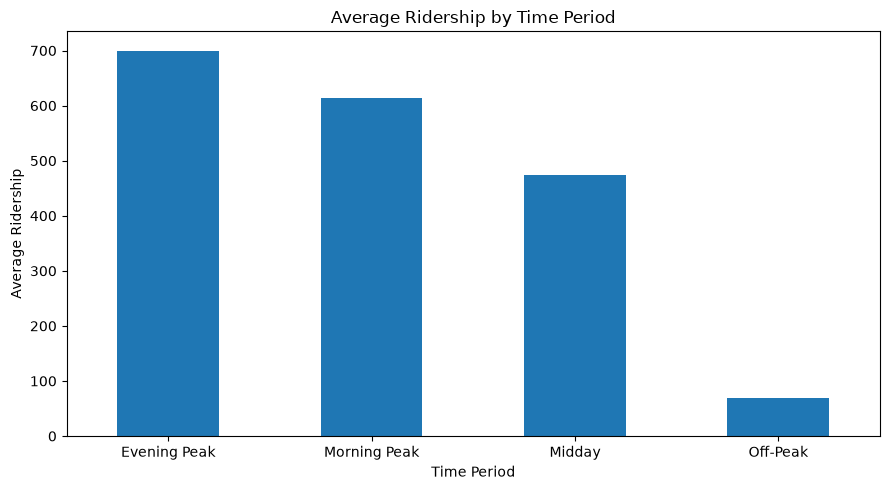

In [20]:
# Peak and off-peak visualization

period_ridership["Average_Ridership"].sort_values(
    ascending=False
).plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Average Ridership by Time Period")
plt.xlabel("Time Period")
plt.ylabel("Average Ridership")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [21]:
# Weekday vs Weekend analysis

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Get day name
df["Day"] = df["Date"].dt.day_name()

# Ridership by day of week
day_ridership = df.groupby("Day")["Ridership"].agg(
    Total_Ridership="sum",
    Average_Ridership="mean"
)

# Arrange days in calendar order
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_ridership = day_ridership.reindex(day_order)

print("Ridership by day of week:")
print(day_ridership)

print("\nDay with highest average ridership:")
print(day_ridership["Average_Ridership"].idxmax())

print(
    "Average ridership:",
    day_ridership["Average_Ridership"].max()
)

Ridership by day of week:
           Total_Ridership  Average_Ridership
Day                                          
Monday             6111371         392.358179
Tuesday            5299718         390.144140
Wednesday          4673565         401.509021
Thursday           4672891         402.280561
Friday             4889322         368.393761
Saturday           4593240         344.837838
Sunday             3597775         271.080093

Day with highest average ridership:
Thursday
Average ridership: 402.28056129476585


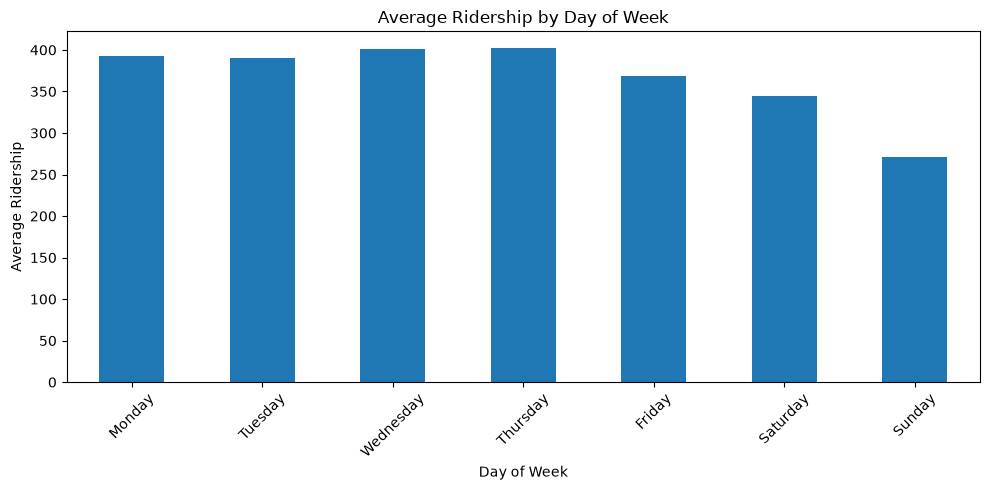

In [22]:
# Average ridership by day of week

day_ridership["Average_Ridership"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Average Ridership by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Ridership")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [23]:
# Weekday vs Weekend comparison

df["Day_Type"] = df["Date"].dt.dayofweek.apply(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

day_type_ridership = df.groupby("Day_Type")["Ridership"].agg(
    Total_Ridership="sum",
    Average_Ridership="mean"
)

print("Weekday vs Weekend ridership:")
print(day_type_ridership)

print("\nDay type with higher average ridership:")
print(
    day_type_ridership["Average_Ridership"].idxmax()
)

print(
    "Average ridership:",
    day_type_ridership["Average_Ridership"].max()
)

Weekday vs Weekend ridership:
          Total_Ridership  Average_Ridership
Day_Type                                    
Weekday          25646867         390.434585
Weekend           8191015         308.025534

Day type with higher average ridership:
Weekday
Average ridership: 390.4345847034466


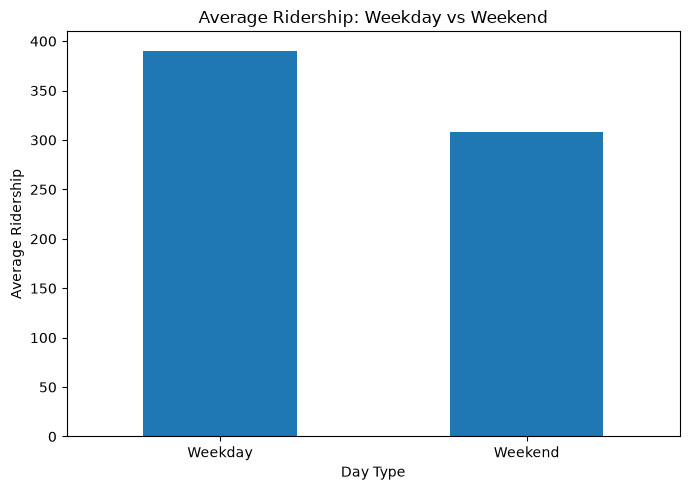

In [24]:
# Weekday vs Weekend visualization

day_type_ridership["Average_Ridership"].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Average Ridership: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Ridership")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [25]:
# Busiest station-hour combinations

station_hour_ridership = (
    df.groupby(["Station", "Hour"])["Ridership"]
    .sum()
    .sort_values(ascending=False)
)

print("Top 20 busiest station-hour combinations:")
print(station_hour_ridership.head(20))

Top 20 busiest station-hour combinations:
Station                                     Hour
Mahatma Gandhi Road                         18      159547
Benniganahalli                              9       154784
Mahatma Gandhi Road                         19      142517
Indiranagar                                 18      142005
Trinity                                     18      134575
Cubbon Park                                 18      131980
Benniganahalli                              10      128253
Nadaprabhu Kempegowda Station, Majestic     18      125602
Benniganahalli                              8       124526
Nadaprabhu Kempegowda Station, Majestic     19      123100
Indiranagar                                 19      119829
Nadaprabhu Kempegowda Station, Majestic     17      116148
Baiyappanahalli                             9       113272
Mahatma Gandhi Road                         17      112267
Nadaprabhu Kempegowda Station, Majestic     9       111541
Dr. B. R. Ambedkar Stati

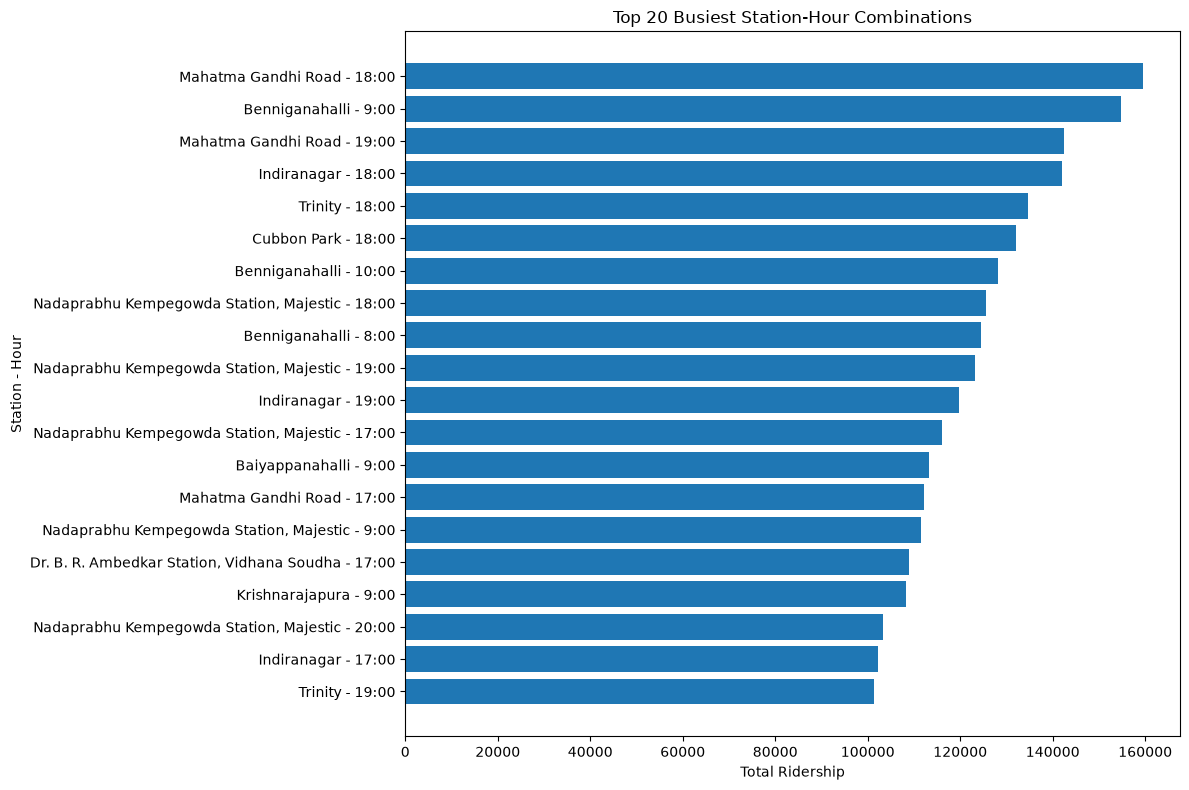

In [26]:
# Top 20 busiest station-hour combinations visualization

top_20_station_hour = station_hour_ridership.head(20)

# Create readable labels
labels = [
    f"{station} - {hour}:00"
    for station, hour in top_20_station_hour.index
]

plt.figure(figsize=(12, 8))

plt.barh(
    labels[::-1],
    top_20_station_hour.values[::-1]
)

plt.title("Top 20 Busiest Station-Hour Combinations")
plt.xlabel("Total Ridership")
plt.ylabel("Station - Hour")

plt.tight_layout()
plt.show()

### Station-Hour Hotspot Analysis

The station-hour analysis identifies the busiest station and hour combinations across the dataset.

The highest-demand combination is Mahatma Gandhi Road at 18:00, with a total ridership of 159,547 across the available dates. Several other high-demand combinations are concentrated between 17:00 and 19:00.

This indicates that evening peak hours are important periods for crowd-demand monitoring and prediction. These station-hour patterns can later support crowd forecasting, station-level alerts, and train frequency optimization.

Note: High ridership indicates high passenger demand, but it does not by itself confirm physical congestion. Occupancy, capacity, or passenger flow data would be required for direct congestion measurement.

### Station-Hour Hotspot Analysis

The station-hour analysis identifies the busiest station and hour combinations across the dataset.

The highest-demand combination is Mahatma Gandhi Road at 18:00, with a total ridership of 159,547 across the available dates. Several other high-demand combinations are concentrated between 17:00 and 19:00.

This indicates that evening peak hours are important periods for crowd-demand monitoring and prediction. These station-hour patterns can later support crowd forecasting, station-level alerts, and train frequency optimization.

Note: High ridership indicates high passenger demand, but it does not by itself confirm physical congestion. Occupancy, capacity, or passenger flow data would be required for direct congestion measurement.

### Station-Hour Hotspot Analysis

The station-hour analysis identifies the busiest station and hour combinations across the dataset.

The highest-demand combination is Mahatma Gandhi Road at 18:00, with a total ridership of 159,547 across the available dates. Several other high-demand combinations are concentrated between 17:00 and 19:00.

This indicates that evening peak hours are important periods for crowd-demand monitoring and prediction. These station-hour patterns can later support crowd forecasting, station-level alerts, and train frequency optimization.

Note: High ridership indicates high passenger demand, but it does not by itself confirm physical congestion. Occupancy, capacity, or passenger flow data would be required for direct congestion measurement.